**Clasificación de comida saludable**

Este dataset incluye registros de diferentes alimentos y sus propiedades nutricionales, contando al final con una columna que indica si es saludable o no. El modelo aprenderá a decir si un alimento es saludable o no.

**PASO 1: DATASET**

In [1]:
import pandas as pd
import numpy as np

In [22]:
# Cargar desde url
url = "https://raw.githubusercontent.com/nsteiner/Healthy_Foods_Classifier/refs/heads/main/labels.csv"
df = pd.read_csv(url)

In [23]:
df

,Food_Id,Calories,Total_Fat_DV,Sat_Fat_DV,Trans_Fat,Cholesterol_DV,Sodium_DV,Carbs_DV,Fiber_DV,Total_Sugars (g),Added_Sugars_DV,Protein (g),Vitamin_D_DV,Calcium_DV,Iron_DV,Potassium_DV,Healthy(0)/Unhealthy(1)/In Moderation(2)
0,1,95.0,0,0,0.0,0,0,8,17.0,19.0,0,0.5,0,1,1,5,0
1,2,80.0,10,5,0.0,0,0,1,11.0,0.0,0,1.0,0,0,2,6,2
2,3,105.0,0,0,0.0,0,0,9,12.0,14.0,0,1.3,0,0,1,12,0
3,4,80.0,1,0,0.0,0,0,8,14.0,15.0,0,1.0,0,0,2,2,0
4,5,45.0,0,0,0.0,0,0,3,9.0,9.0,0,0.9,0,3,0,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
216,217,240.0,17,10,0.0,0,23,10,11.0,0.0,0,3.0,0,2,2,10,1
217,218,570.0,41,80,0.0,30,58,16,14.0,3.0,2,29.0,0,45,20,6,1
218,219,512.0,47,80,0.3,237,56,1,9.0,1.4,0,40.0,20,24,19,10,1
219,220,1012.0,69,90,0.5,89,37,26,1.0,24.0,48,58.0,1,29,29,14,1


Analisis exploratorio de datos (EDA):

In [24]:
# Información del database:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 221 entries, 0 to 220
Data columns (total 17 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Food_Id                                   221 non-null    int64  
 1   Calories                                  221 non-null    float64
 2   Total_Fat_DV                              221 non-null    int64  
 3   Sat_Fat_DV                                221 non-null    int64  
 4   Trans_Fat                                 221 non-null    float64
 5   Cholesterol_DV                            221 non-null    int64  
 6   Sodium_DV                                 221 non-null    int64  
 7   Carbs_DV                                  221 non-null    int64  
 8   Fiber_DV                                  221 non-null    float64
 9   Total_Sugars (g)                          221 non-null    float64
 10  Added_Sugars_DV                       

In [27]:
# Estadística Descriptiva:
df.describe()

,Food_Id,Calories,Total_Fat_DV,Sat_Fat_DV,Trans_Fat,Cholesterol_DV,Sodium_DV,Carbs_DV,Fiber_DV,Total_Sugars (g),Added_Sugars_DV,Protein (g),Vitamin_D_DV,Calcium_DV,Iron_DV,Potassium_DV,Healthiness
count,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.00000,221.000000,221.000000
mean,111.000000,269.152941,16.371041,18.918552,0.099548,12.705882,17.470588,9.805430,13.658371,8.208597,5.466063,13.040724,1.085973,10.506787,11.40724,8.733032,0.791855
std,63.941379,280.200505,21.036934,26.877207,0.765180,26.554051,22.889364,10.817627,17.449467,11.338862,18.670224,15.884520,3.517079,16.778942,14.68539,9.132671,0.853936
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,56.000000,80.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2.000000,0.700000,0.000000,1.500000,0.000000,1.000000,1.00000,3.000000,0.000000
50%,111.000000,170.000000,10.000000,8.000000,0.000000,0.000000,6.000000,6.000000,8.000000,4.000000,0.000000,5.000000,0.000000,3.000000,6.00000,6.000000,1.000000
75%,166.000000,379.000000,24.000000,26.000000,0.000000,17.000000,27.000000,15.000000,17.000000,12.000000,0.000000,21.000000,0.000000,14.000000,16.00000,12.000000,2.000000
max,221.000000,1608.000000,140.000000,174.000000,11.000000,237.000000,112.000000,52.000000,116.000000,76.000000,148.000000,73.000000,20.000000,100.000000,88.00000,52.000000,2.000000


In [82]:
# Cambiamos el nombre de la ultima tabla por que es muy largo:
df = df.rename(columns = {'Healthy(0)/Unhealthy(1)/In Moderation(2)': 'Healthiness'})
df = df.rename(columns = {'Total_Sugars (g)': 'Total_Sugars_G'})
df = df.rename(columns = {'Protein (g)': 'Proteins_G'})
print(df)

     Food_Id  Calories  Total_Fat_DV  Sat_Fat_DV  Trans_Fat  Cholesterol_DV  \
0          1      95.0             0           0        0.0               0   
1          2      80.0            10           5        0.0               0   
2          3     105.0             0           0        0.0               0   
3          4      80.0             1           0        0.0               0   
4          5      45.0             0           0        0.0               0   
..       ...       ...           ...         ...        ...             ...   
216      217     240.0            17          10        0.0               0   
217      218     570.0            41          80        0.0              30   
218      219     512.0            47          80        0.3             237   
219      220    1012.0            69          90        0.5              89   
220      221     595.0            42          65        1.6              35   

     Sodium_DV  Carbs_DV  Fiber_DV  Total_Sugars_G 

In [28]:
df["Healthiness"].value_counts()

,count
Healthiness,
0,108
2,62
1,51


In [31]:
# Procesamiento de Datos
# Sería mejor si el target del modelo fuera una predicción binaria. Por lo que todos los alimentos de
# salubridad moderada serán catalogados como no saludables.
df["Healthiness"] = df["Healthiness"].replace(2,1)
df["Healthiness"].value_counts()

,count
Healthiness,
1,113
0,108


In [57]:
# Visualización de 3 gráficas para mejor comprensión:
import matplotlib.pyplot as plt
import seaborn as sns

In [61]:
plt.figure(figsize=(16, 6))

<Figure size 1600x600 with 0 Axes>

<Figure size 1600x600 with 0 Axes>

Text(0, 0.5, 'Total de Alimentos')

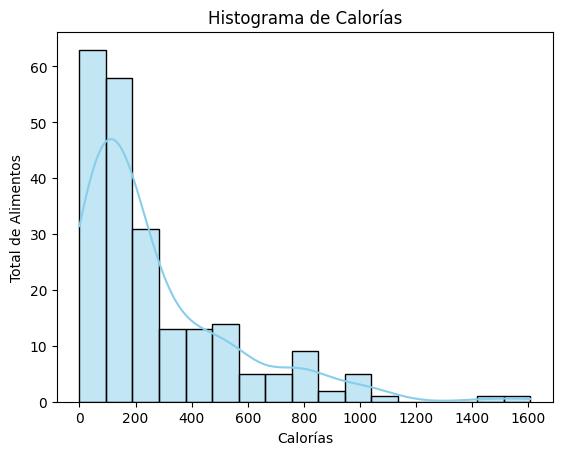

In [90]:
# 1. Histograma de Calorías
plt.subplot(1, 1, 1)
sns.histplot(data=df, x='Calories', kde=True, color='skyblue')
plt.title('Histograma de Calorías')
plt.xlabel('Calorías')
plt.ylabel('Total de Alimentos')

Text(0, 0.5, 'Calorías (kcal)')

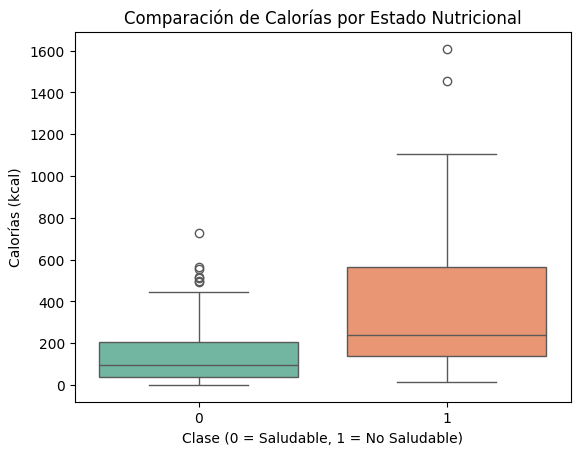

In [88]:
# 2. Boxplot de calorías por categoría de salubridad
sns.boxplot(data=df, x='Healthiness', y='Calories', hue='Healthiness', palette='Set2', legend=False)
plt.title('Comparación de Calorías por Estado Nutricional')
plt.xlabel('Clase (0 = Saludable, 1 = No Saludable)')
plt.ylabel('Calorías (kcal)')

Text(0, 0.5, 'Grasas Totales (g)')

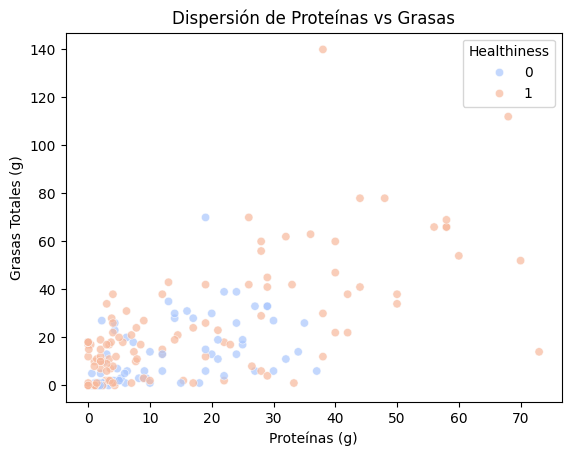

In [91]:
# 3. Diagrama de dispersión de proteínas vs. grasas
sns.scatterplot(data=df, x='Proteins_G', y='Total_Fat_DV', hue='Healthiness', palette='coolwarm', alpha=0.7)
plt.title('Dispersión de Proteínas vs Grasas')
plt.xlabel('Proteínas (g)')
plt.ylabel('Grasas Totales (g)')

**Justificación de los graficos**

- El histograma toma la variable de calorías para contabilizar rangos de cantidad de calorías por cada 100g y el número de alimentos dentro de cada rango. Es útil para observar la distribución de las calorías en los muchos registros de diferentes alimentos en nuestro dataset.
- En el boxplot, vemos 2 graficos que comparan la disperción del valor de calorías entre los alimentos saludables y los que no lo son. Podemos ver como generalmente los alimentos saludables aportan menos calorías que los no saludables.
- En el diagrama de dispersión comparamos las proteías con las grasas de cada alimento por cada 100 gramos de estos. Osverbamos que hay una moderada correlación positiva entre estos 2 features. Sin embargo hay algunos outliers los cuales parecen ser incoherentes, para estos casos especiales se puede explicar su insalubridad por medio de otras variables como "azucar" o "sodio" no consideradas en este gráfico 2D.


**PASO 2: MODELO**

In [101]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
import joblib
import os

In [94]:
# Ejes X (variables recomendables) y Y (target o variable a predecir):
X = df.drop(columns=['Food_Id','Healthiness'])
y = df['Healthiness']

In [95]:
# División del dataset en 80% para entrenamiento y 20% para predicción:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [96]:
# Entrenamiento del Primer Modelo (Regresión Logística)
primer_modelo = LogisticRegression(max_iter=1000, random_state=42)
primer_modelo.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [98]:
# predicción del 2do grupo de registros:
predicciones = primer_modelo.predict(X_test)

In [99]:
# Evaluaciones
print(f"Accuracy: {accuracy_score(y_test, predicciones):.4f}")
print(f"F1-Score: {f1_score(y_test, predicciones):.4f}")
print("\nReporte Estadístico Completo:")
print(classification_report(y_test, predicciones))

Accuracy: 0.7556
F1-Score: 0.7556

Reporte Estadístico Completo:
              precision    recall  f1-score   support

           0       0.74      0.77      0.76        22
           1       0.77      0.74      0.76        23

    accuracy                           0.76        45
   macro avg       0.76      0.76      0.76        45
weighted avg       0.76      0.76      0.76        45



In [100]:
# Guardamos el Primer Modelo
nombre_archivo = "logistic_regression_model.pkl"
joblib.dump(primer_modelo, nombre_archivo)

['logistic_regression_model.pkl']

In [102]:
# Entrenamiento del segundo modelo (Ramdom Forest)
segundo_modelo = RandomForestClassifier(n_estimators=100, random_state=42)
segundo_modelo.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [103]:
# predicción del 2do grupo:
predicciones_2 = segundo_modelo.predict(X_test)

In [105]:
# Evaluaciones
print("\n=== MÉTRICAS: RANDOM FOREST ===")
print(f"Accuracy: {accuracy_score(y_test, predicciones_2):.4f}")
print(f"F1-Score: {f1_score(y_test, predicciones_2):.4f}")
print("\nReporte Estadístico Completo:")
print(classification_report(y_test, predicciones_2))


=== MÉTRICAS: RANDOM FOREST ===
Accuracy: 0.7556
F1-Score: 0.7660

Reporte Estadístico Completo:
              precision    recall  f1-score   support

           0       0.76      0.73      0.74        22
           1       0.75      0.78      0.77        23

    accuracy                           0.76        45
   macro avg       0.76      0.75      0.76        45
weighted avg       0.76      0.76      0.76        45



In [106]:
# Guardamos el Segundo Modelo
nombre_archivo = "ramdom_forest_model.pkl"
joblib.dump(segundo_modelo, nombre_archivo)

['ramdom_forest_model.pkl']

Evaluación de los modelos

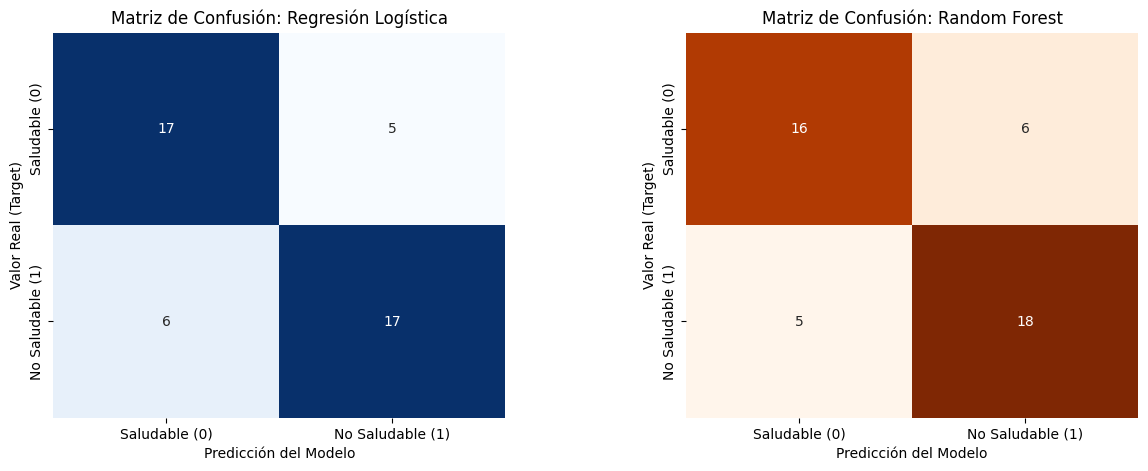

In [108]:
#Heatmap primer modelo:
from sklearn.metrics import confusion_matrix

# 1. Calcular las matrices de confusión para ambos modelos
conf_1 = confusion_matrix(y_test, predicciones)
conf_2 = confusion_matrix(y_test, predicciones_2)

# 2. Configurar el lienzo horizontal (figsize balanceado para evitar aplastamiento)
plt.figure(figsize=(14, 5))

# =========================================================================
# MATRIZ 1: Regresión Logística
# =========================================================================
plt.subplot(1, 2, 1)
sns.heatmap(conf_1, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Saludable (0)', 'No Saludable (1)'],
            yticklabels=['Saludable (0)', 'No Saludable (1)'])
plt.title('Matriz de Confusión: Regresión Logística')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real (Target)')

# =========================================================================
# MATRIZ 2: Random Forest
# =========================================================================
plt.subplot(1, 2, 2)
sns.heatmap(conf_2, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Saludable (0)', 'No Saludable (1)'],
            yticklabels=['Saludable (0)', 'No Saludable (1)'])
plt.title('Matriz de Confusión: Random Forest')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real (Target)')

# 3. Ajustar márgenes y desplegar
plt.subplots_adjust(wspace=0.4)
plt.show()

Los resultados son muy interesantes. Ambos modelos obtuvieron el mismo porcentaje de predicciones correctas (34 de 55), sin embargo, la distribución de las predicciones equivocadas es ligeramente diferente. La regresión logistica brinda un falso negativo más que el metodo de bosque aleatorio, pero un falso positivo menos que este. Dependiendo de los enfoques que podamos tomar luego, mientras tanto es preferible el 2do modelo, ya que un falso negativo podría resultar más peligroso para una persona que requiera de una dieta estricta o para cuidar su salud.